# Sheet 3 - Models of Neural Systems - Computer Practical
### Visual Receptive Fields
#### Group members : Rezwana Hussainzada, Abed Al Karim Taha, Salva Vali Zadeh
*AI usage : "AI tools have been used to produce parts of this solution"*

----
**1. Visual stimulus** A commonly used stimulus to study the early visual system is the sinusoidal grating:
$$
s(x, y) = A cos(Kx cosΘ + Ky sinΘ − Φ),
$$
where $x$, $y$ are the spatial coordinates, $K$ is the spatial frequency, $Θ$ is the orientation, $Φ$ is the spatial phase and $A$ is the contrast amplitude.

*(a)* Approximate the visual field $(x, y)$ with a 2-dimensional grid of uniformly-distributed photoreceptors(retina) at $(x_i, y_j) = (−x_0+iΔx,−y_0+jΔy)$ for $i = 0, 1, . . . , \frac{2x_0}{Δx}$ and $j = 0, 1, . . . , \frac{2y_0}{Δy}$ where $x_0$ and $y_0$ determines the size of the visual field and $Δx$, $Δy$ determines its sampling. Since visual field sizes are specified in degrees, we take this to be the appropriate unit for $x$ and $y$. Take $x_0 = 5◦$, $y_0 = 5◦$ (hence a visual field of size $(10◦)^2$). Hint: You can use numpy.meshgrid to generate such a grid.


*Solution:*

Number of x samples : 51, number of y samples : 51

X is a matrix with shape (51, 51), where each cell contains the x-value for that column.

Y is a matrix with shape (51, 51), where each cell contains the y-value for that row.

The grid is defined by X and Y together, forming a set of points with shape (51, 51), where each cell corresponds to an ordered pair (x, y).


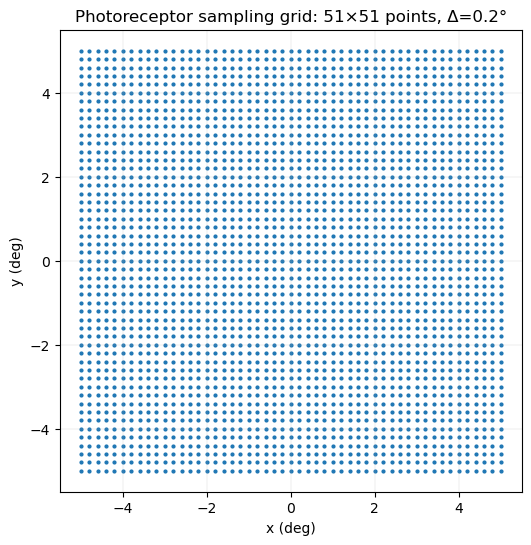

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 5
y0 = 5
dx = 0.2
dy = dx

x = np.arange(-x0, x0 + dx/2, dx)
y = np.arange(-y0, y0 + dy/2, dy)

numx = x.size
numy = y.size

print(f"Number of x samples : {numx}, number of y samples : {numy}\n")

X, Y = np.meshgrid(x, y)

print(f"X is a matrix with shape {X.shape}, where each cell contains the x-value for that column.\n")
print(f"Y is a matrix with shape {Y.shape}, where each cell contains the y-value for that row.\n")
print(f"The grid is defined by X and Y together, forming a set of points with shape {X.shape}, where each cell corresponds to an ordered pair (x, y).")

plt.figure(figsize=(6,6))
plt.scatter(X.ravel(), Y.ravel(), s=4)
plt.xlabel('x (deg)')
plt.ylabel('y (deg)')
plt.title(f'Photoreceptor sampling grid: {numx}×{numy} points, Δ={dx}°')
plt.gca().set_aspect('equal', 'box')
plt.xlim(-x0-0.5, x0+0.5)
plt.ylim(-y0-0.5, y0+0.5)
plt.grid(True, linewidth=0.3, alpha=0.5)
plt.show()





*(b)* Compute a sinusoidal grating on the grid specified in (a) with the following grating parameters: $Θ = 0$, $Φ = 0$, $K = π\frac{1}{degree}$ , $A = 1$. Use the matplotlib.pyplot.imshow function to plot the 2-dimensional map.

*Solution:*

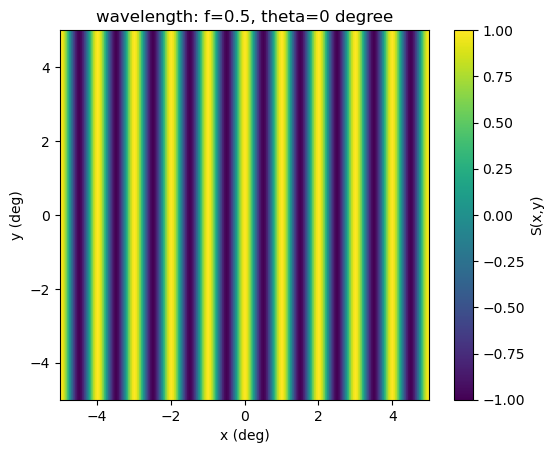

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 5
y0 = 5
dx = 0.05  # we choose 0.05<0.2 to have better resolution.
dy = dx

x = np.arange(-x0, x0 + dx/2, dx)
y = np.arange(-y0, y0 + dy/2, dy)

numx = x.size
numy = y.size

X, Y = np.meshgrid(x, y)

# s(x, y) = Acos(Kx cosΘ + Ky sinΘ − Φ) Static Counter-phase grating

A = 1   #contrast amplitude
w = 0.5     #wavelength (degree)
K = np.pi * 1 / w     #spatial frequency
theta = 0  #oriantation (degree)
# (degree * \pi) / 180 = rad
Theta = 0   #oriantation (rad)
Phi = 0      #spatial phase


S = A * np.cos(K * (X * np.cos(Theta) + Y * np.sin(Theta)) - Phi)

plt.imshow(S, origin='lower', extent=[-x0, x0, -y0, y0], aspect='equal')
plt.xlabel('x (deg)')
plt.ylabel('y (deg)')
plt.title(f'wavelength: f={w}, theta={Theta} degree')
plt.colorbar(label='S(x,y)')
plt.show()

*(c)* Vary the orientation Θ and the spatial frequency K and plot the resulting gratings.

*Soultion:*

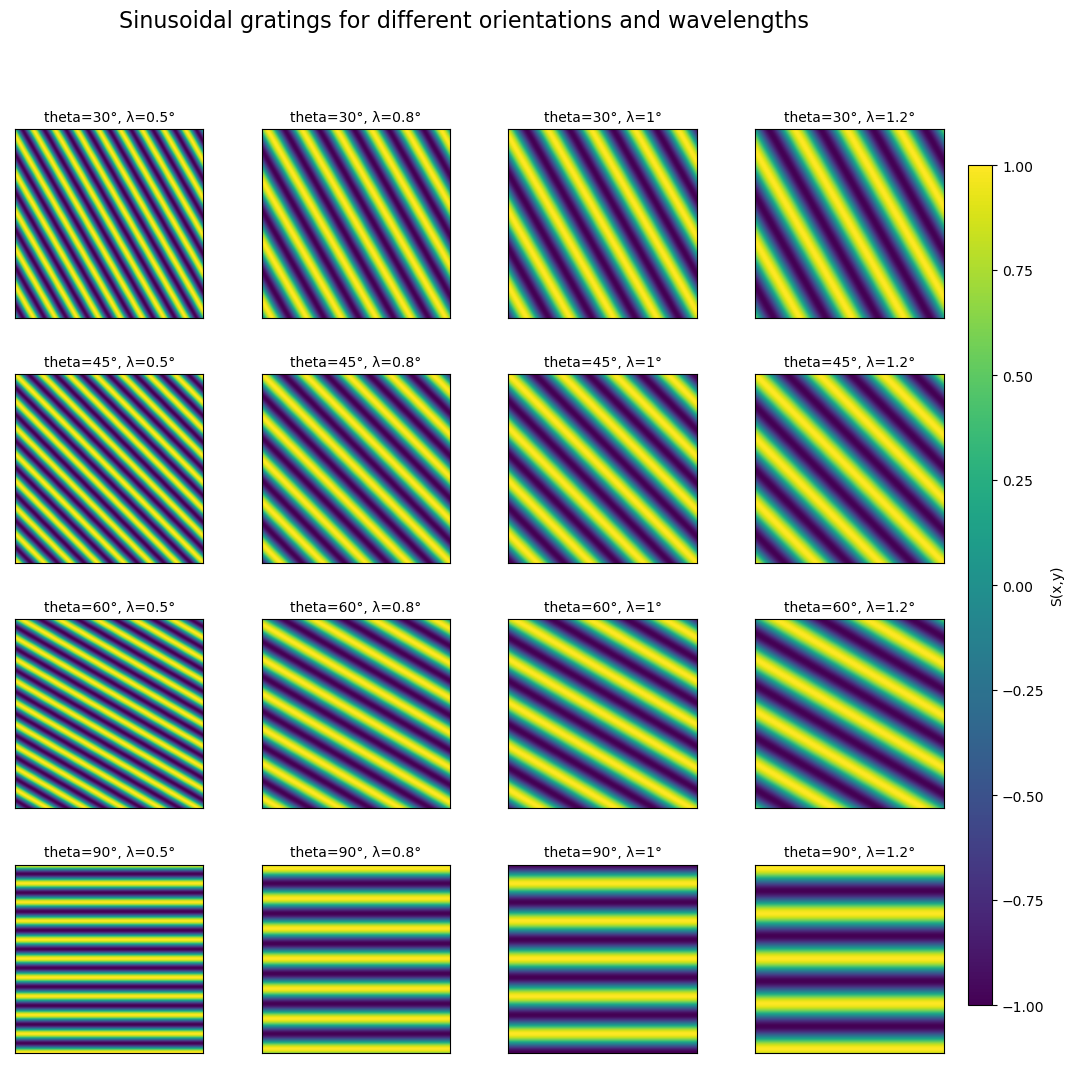

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 5
y0 = 5
dx = 0.05
dy = dx

x = np.arange(-x0, x0 + dx/2, dx)
y = np.arange(-y0, y0 + dy/2, dy)

numx = x.size
numy = y.size

X, Y = np.meshgrid(x, y)

A = 1
Phi = 0
theta = [30, 45, 60, 90]
Theta = [np.deg2rad(t) for t in theta]
Wavelength = [0.5, 0.8, 1, 1.2] #degree
K = [np.pi * 1 / w for w in Wavelength]  #spatial frequency


n = len(Theta)
m = len(K)

# Create figure with 4x4 subplots
fig, axes = plt.subplots(n, m, figsize=(12, 12))
fig.suptitle('Sinusoidal gratings for different orientations and wavelengths', fontsize=16)

for i in range(n):
    for j in range(m):
        S = A * np.cos(K[j] * (X * np.cos(Theta[i]) + Y * np.sin(Theta[i])) - Phi)
        ax = axes[i, j]
        im = ax.imshow(S, origin='lower', extent=[-x0, x0, -y0, y0], aspect='equal', cmap='viridis')
        ax.set_title(f'theta={theta[i]}°, λ={Wavelength[j]}°', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

# Adjust spacing and add colorbar
plt.subplots_adjust(wspace=0.3, hspace=0.3)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # x, y, width, height
fig.colorbar(im, cax=cbar_ax, label='S(x,y)')

plt.show()

**2. A model of receptive fields** A receptive field (RF) describes the “sensitivity” of a neuron to its inputs, depending on their position in the visual field. A convenient mathematical approximation of a receptive field is provided by the Gabor function:
$$
D_s(x, y) =\frac{1}{2πσ_xσ_y}exp(− \frac{x^2}{2σ^2_x}-\frac{y^2}{2σ^2_y})cos(kx − ϕ),
$$
where $k$ is the preferred spatial frequency, $ϕ$ is the preferred spatial phase and $σ_x$, $σ_y$ define the receptive field sizes.

*(a)* Implement a Gabor function as a model of a receptive field with preferred spatial frequency $k = π\frac{1}{degree}$, preferred spatial phase $ϕ = 0$ and receptive field size $σ_x = 2◦$, $σ_y = 1◦$. Use the same dimension $(x_0, y_0)$ as in Problem 1. Plot this Gabor receptive field.

*Solution:*


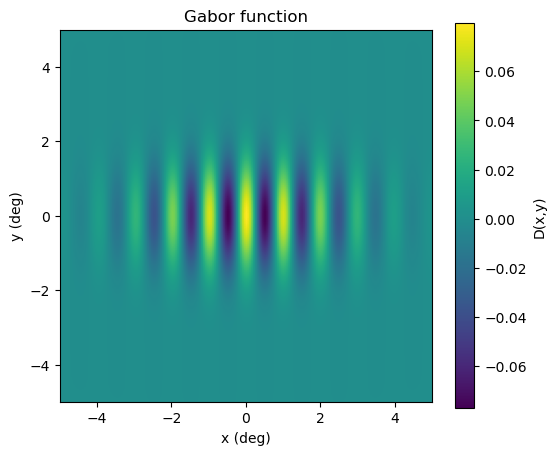

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 5
y0 = 5
dx = 0.05
dy = dx

x = np.arange(-x0, x0 + dx/2, dx)
y = np.arange(-y0, y0 + dy/2, dy)

X, Y = np.meshgrid(x, y)

numx = x.size
numy = y.size

w = 0.5     #wavelength (degree)
k = np.pi * 1 / w     #preffered spatial frequency
sigma_x = 2
sigma_y = 1
Phi = 0

D = (1/(2*np.pi*sigma_x*sigma_y)) * np.exp(-(X**2/(2*sigma_x**2)) - (Y**2/(2*sigma_y**2))) * np.cos(k*X - Phi)

plt.figure(figsize=(6,5))
plt.imshow(D, origin='lower', extent=[-x0,x0,-y0,y0], aspect='equal')
plt.xlabel('x (deg)')
plt.ylabel('y (deg)')
plt.title(f'Gabor function')
plt.colorbar(label='D(x,y)')
plt.show()

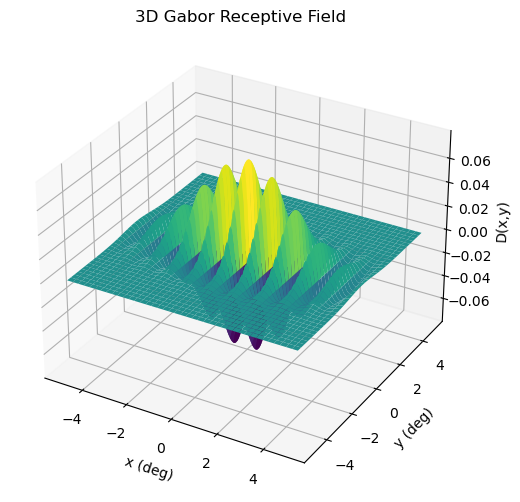

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Grid
x0 = 5
y0 = 5
dx = 0.05
dy = dx
x = np.arange(-x0, x0 + dx/2, dx)
y = np.arange(-y0, y0 + dy/2, dy)
X, Y = np.meshgrid(x, y)

# Gabor parameters
w = 0.5
k = np.pi / w
sigma_x = 2
sigma_y = 1
Phi = 0

# Gabor function
D = (1/(2*np.pi*sigma_x*sigma_y)) * np.exp(-(X**2/(2*sigma_x**2)) - (Y**2/(2*sigma_y**2))) * np.cos(k*X - Phi)

# 3D plot
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')


ax.plot_surface(X, Y, D, cmap='viridis', edgecolor='none')

ax.set_xlabel('x (deg)')
ax.set_ylabel('y (deg)')
ax.set_zlabel('D(x,y)')
ax.set_title('3D Gabor Receptive Field')

plt.show()


*(b)* What are the optimal stimuli for a neuron with such a RF? Where can you find a neuron with such an RF? Is this RF separable or not? Does this RF characterize a simple cell or a complex cell? Why?

*Solution:*

The optimal stimuli for a neuron with an RF described by a Gabor function are those that maximize the neuron’s response. The sensitive area of the neuron is determined by a sinusoidal wave in the middle of the RF, so it responds best to grating stimuli. To maximize the response, the grating must be aligned with the RF in orientation, spatial frequency, and phase.

The spatial receptive-field structure of a simple cell in cat V1 can be described by a Gabor function. Let's examine whether the RF is separable (i.e., can we write $D_s(x,y)$ as $D_s(x)×D_s(y)$):
$$
\begin{align}
D_s(y) &= \frac{1}{\sigma_y} \exp\Big(-\frac{y^2}{2\sigma_y^2}\Big) \\
D_s(x) &= \frac{1}{2\pi\sigma_x} \exp\Big(-\frac{x^2}{2\sigma_x^2}\Big) \cos(kx-\phi) \\
D_s(y) \times D_s(x) &= \frac{1}{\sigma_y} \exp\Big(-\frac{y^2}{2\sigma_y^2}\Big)
\times \frac{1}{2\pi\sigma_x} \exp\Big(-\frac{x^2}{2\sigma_x^2}\Big) \cos(kx-\phi) \\
&= \frac{1}{2\pi\sigma_x\sigma_y} \exp\Big(- \frac{x^2}{2\sigma_x^2} - \frac{y^2}{2\sigma_y^2}\Big) \cos(kx - \phi) = D_s(x,y)
\end{align}
$$
RF characterize a simple cell because depends on the phase of the stimulus, and it cares where light and dark bars of the stimulus fall within its receptive field.

*(c)* The linear response rs of a neuron with receptive field Ds to a visual stimulus s is given by
$$
r_s =\int s(x, y)D_s(x, y)dxdy.
$$
Numerically this corresponds to
$$
r_s =(s· D_s)ΔxΔy =\Sigma^{\frac{2x_0}{Δx}}_{i=0}\Sigma^{\frac{2y_0}{Δxy}}_{j=0}s(x_i, y_j)D_s(x_i, y_j)ΔxΔy.
$$
Thus, the RF is separable.

This RF characterizes a simple cell because it depends on the phase of the stimulus and is sensitive to the precise locations of light and dark bars within its receptive field.
*Solution:*

In [6]:
import numpy as np

# Grid parameters
x0 = 5
y0 = 5
dx = 0.05  # we choose 0.05<0.2 to have better resolution.
dy = dx

x = np.arange(-x0, x0 + dx/2, dx)
y = np.arange(-y0, y0 + dy/2, dy)

numx = x.size
numy = y.size

# Create 2D grid for the visual field
X, Y = np.meshgrid(x, y)

# Stimulus: Sinusoidal grating, which is a Static Counter-phase grating
# stimulus parameters
A = 1   #contrast amplitude
w = 0.5     #wavelength (degree)
K = np.pi * 1 / w     #spatial frequency
theta = 0  #oriantation (degree)
# (degree * \pi) / 180 = rad
Theta = 0   #oriantation (rad)
Phi = 0      #spatial phase

# Grating stimulus
S = A * np.cos(K * (X * np.cos(Theta) + Y * np.sin(Theta)) - Phi)

# Receptive field: Gabor function
w = 0.5
k = np.pi / w
sigma_x = 2
sigma_y = 1
Phi = 0

# Gabor function
D = (1/(2*np.pi*sigma_x*sigma_y)) * np.exp(-(X**2/(2*sigma_x**2)) - (Y**2/(2*sigma_y**2))) * np.cos(k*X - Phi)


# Compute linear response rs = ∑∑ S * D * dx * dy

n1 = x.shape[0]
n2 = y.shape[0]

rs = 0
for i in range(n1):
    for j in range(n2):
        rs += S[i][j]*D[i][j]*dx*dy

print("Linear response of the neuron to the grating stimulus:", rs)

Linear response of the neuron to the grating stimulus: 0.4941546676934796


**3. Tuning Curve** A tuning curve describes the dependence of the neuronal response on a parameter of the stimulus such as spatial frequency, orientation or phase. Plot the neuronal response $r$ to the grating from the exercise 1b as a function of:

*(a)* stimulus orientation

*(b)* ratio of the stimulus’ spatial frequency to the cell’s preferred value $\frac{K}{k}$,

*(c)* stimulus’ spatial phase $Φ$.

*Solution:*

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Grid parameters
x0 = 5
y0 = 5
dx = 0.05  # we choose 0.05<0.2 to have better resolution.
dy = dx


x = np.arange(-x0, x0 + dx/2, dx)
y = np.arange(-y0, y0 + dy/2, dy)
n = x.shape[0]
numx = x.size
numy = y.size

# Create 2D grid for the visual field
X, Y = np.meshgrid(x, y)

# Receptive field: Gabor function
w = 0.5
k = np.pi / w
sigma_x = 2
sigma_y = 1
Phi = 0

# Gabor function
D = (1/(2*np.pi*sigma_x*sigma_y)) * np.exp(-(X**2/(2*sigma_x**2)) - (Y**2/(2*sigma_y**2))) * np.cos(k*X - Phi)

def response(D, S):
    return np.sum(D * S) * dx * dy

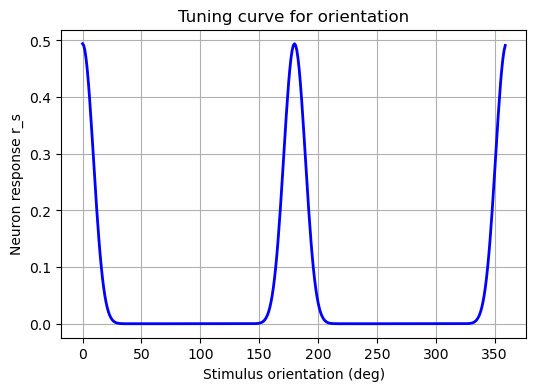

In [8]:
# (a) Tuning curve for orientation
# Stimulus: Sinusoidal grating, which is a Static Counter-phase grating
# stimulus parameters
A = 1   #contrast amplitude
w = 0.5     #wavelength (degree)
K = np.pi * 1 / w     #spatial frequency
dtheta = 1
theta = np.arange(0, 360, dtheta) #orientation
Theta = np.array([np.deg2rad(t) for t in theta])
Phi = 0      #spatial phase

r = []
for th in Theta:
    S = A * np.cos(K * (X * np.cos(th) + Y * np.sin(th)) - Phi)
    r.append(response(D, S))
r = np.array(r)


# Plot tuning curve
plt.figure(figsize=(6,4))
plt.plot(theta, r, 'b-', lw=2)
plt.xlabel('Stimulus orientation (deg)')
plt.ylabel('Neuron response r_s')
plt.title('Tuning curve for orientation')
plt.grid(True)
plt.show()

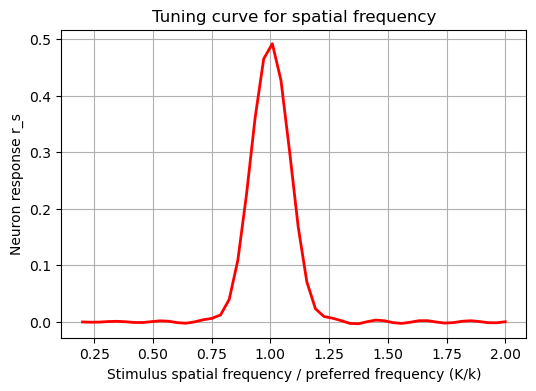

In [9]:
# (b) Tuning curve for spatial frequency
# Define a range of spatial frequencies relative to preferred k
K_ratios = np.linspace(0.2, 2.0, 50)  # K/k from 0.2 to 2
r_freq = []

A = 1   #contrast amplitude
theta = 0  #oriantation (degree)
Theta = 0   #oriantation (rad)
Phi = 0      #spatial phase

for ratio in K_ratios:
    K_stim = ratio * k  # actual stimulus frequency
    S = A * np.cos(K_stim * X - Phi)  # orientation = 0
    A * np.cos(K_stim * (X * np.cos(Theta) + Y * np.sin(Theta)) - Phi)
    r_freq.append(response(D, S))

r_freq = np.array(r_freq)

# Plot
plt.figure(figsize=(6,4))
plt.plot(K_ratios, r_freq, 'r-', lw=2)
plt.xlabel('Stimulus spatial frequency / preferred frequency (K/k)')
plt.ylabel('Neuron response r_s')
plt.title('Tuning curve for spatial frequency')
plt.grid(True)
plt.show()



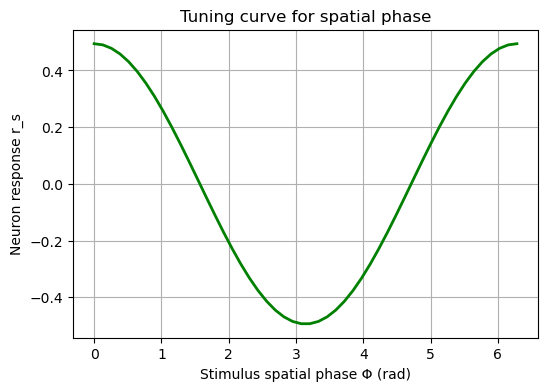

In [10]:
# (c) Tuning curve for spatial phase

# stimulus parameters
A = 1   #contrast amplitude
w = 0.5     #wavelength (degree)
K = np.pi * 1 / w     #spatial frequency
Theta = 0 #orientation


Phi_values = np.linspace(0, 2*np.pi, 50)  # 0 to 2pi
r_phase = []

for phi in Phi_values:
    S = A * np.cos(k * X - phi)  # orientation = 0, spatial frequency = k
    r_phase.append(response(D, S))

r_phase = np.array(r_phase)

# Plot
plt.figure(figsize=(6,4))
plt.plot(Phi_values, r_phase, 'g-', lw=2)
plt.xlabel('Stimulus spatial phase Φ (rad)')
plt.ylabel('Neuron response r_s')
plt.title('Tuning curve for spatial phase')
plt.grid(True)
plt.show()


Characterize the receptive field in terms of its selectivity to position, orientation, spatial frequency, and phase. What would its preferred stimulus be (the stimulus giving rise to maximal response)?

We can see that the preferred spatial frequency of the receptive field matches the spatial frequency of the stimulus $K=k$. Simple cells’ Gabor RFs produce a cosine-shaped tuning curve that depends on the stimulus phase, with the preferred stimulus phase being 0. The neuron reaches its maximum response at 0° and 180° stimulus orientations.

4. Bonus Exercise:
a-


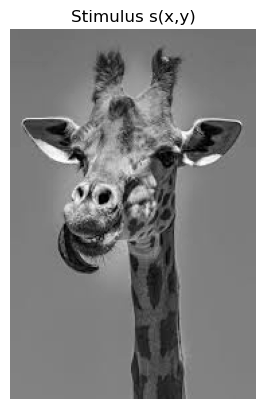

s.shape = (275, 183)


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Load one of your images from Moodle
img = plt.imread("im1.png")   # or "im2.png" or "im3.png"

# Convert to grayscale
if img.ndim == 3:
    img = img.astype(float)
    s = 0.2989*img[:,:,0] + 0.5870*img[:,:,1] + 0.1140*img[:,:,2]
else:
    s = img.astype(float)

# Normalize
s = s - s.min()
if s.max() != 0:
    s = s / s.max()

plt.imshow(s, cmap="gray")
plt.title("Stimulus s(x,y)")
plt.axis("off")
plt.show()

print("s.shape =", s.shape)


b-

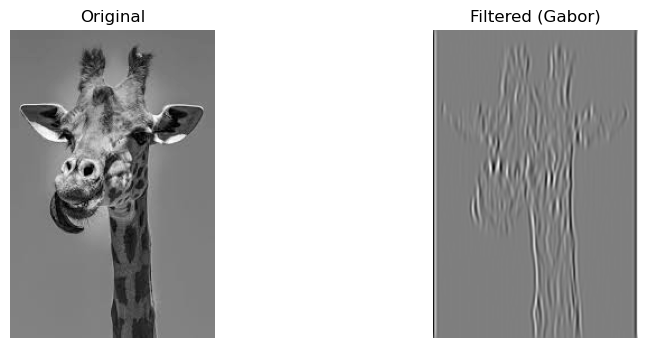

In [13]:
from scipy.signal import fftconvolve

ny, nx = s.shape

# Grid for receptive fields
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
X, Y = np.meshgrid(x, y)

# Gabor parameters
k       = 8 * np.pi
phi     = np.pi/2
sigma_x = 1/8
sigma_y = 1/8
theta   = 0

# Rotated coords
Xp =  X*np.cos(theta) + Y*np.sin(theta)
Yp = -X*np.sin(theta) + Y*np.cos(theta)

# Gabor receptive field
Ds = np.exp(-0.5*((Xp**2)/(sigma_x**2) + (Yp**2)/(sigma_y**2))) * np.cos(k*Xp + phi)

# Correlation via convolution
Ds_conv = Ds[::-1, ::-1]
r = fftconvolve(s, Ds_conv, mode="same")

# Plot results
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(s, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(r, cmap='gray')
plt.title("Filtered (Gabor)")
plt.axis("off")

plt.show()
